In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

In [20]:
#global variables 
DIM = 6
EPS = 1e-15

psi0 = np.zeros(shape=DIM, dtype=complex)
psi0[0] = 1.0+0.j

In [59]:
#test of computation

H_test = gen.router(theta=np.pi)

#print(H_test)

compl_test = kr.get_complexity(H_test, psi0, threshold=EPS)[1]

#print(H_kryl)

print(compl_test.real)

#Ho sbagliato il conto analitico. Questo rispetta il limite superiore; forse gli indiani avevano ragione

1.394444444444444


In [67]:
n_thetas = 500000
theta_max = np.pi

thetas = np.linspace(0, theta_max, n_thetas)

compls = np.ndarray(shape=n_thetas, dtype=complex)

for i in range(n_thetas):
    H = gen.router(theta=thetas[i])
    compls[i] = kr.get_complexity(H, psi0, EPS)[1]

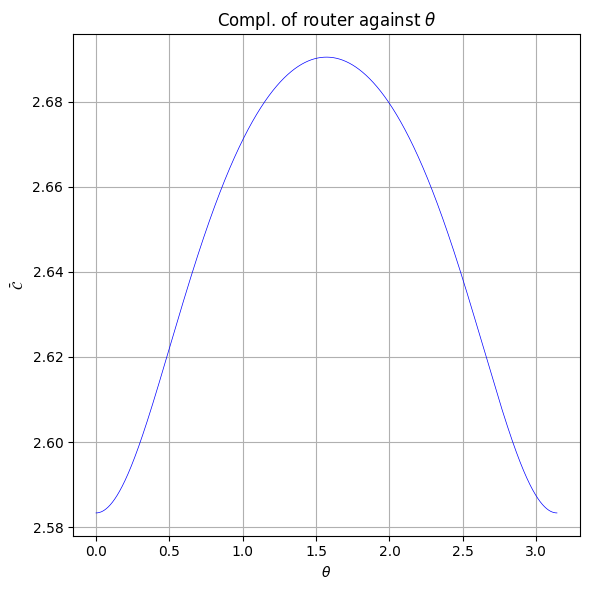

In [69]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.set_title(r"Compl. of router against $\theta$")
axx.grid(True)

axx.set_xlabel(r"$\theta$")
axx.set_ylabel(r"$\bar{\mathcal{C}}$")

#axx.set_ylim(bottom=-0.1+min(compls.real[1:-2]), top=max(compls.real[1:-2]))
axx.plot(thetas[1:-2], compls.real[1:-2], linewidth=0.5, color="blue")

#axx.axhline(y=0.5*(4-1), label="Degenerate upper-bound", linestyle="--", color="red")
#axx.axhline(y=0.5*(6-1), label="Non-deg. upper-bound", linestyle="--", color="red")

#axx.legend()

plt.show()


In [120]:
#varying gamma

gammas = np.linspace(0, 5, 100)

In [122]:
n_thetas = 10000
theta_max = np.pi

thetas = np.linspace(0, theta_max, n_thetas)

compl_gammas = np.ndarray(shape=(len(gammas),n_thetas), dtype=complex)

i=0
for gamma in gammas:
    for j in range(n_thetas):
        H = gen.router(gamma=gamma, theta=thetas[j])
        compl_gammas[i,j] = kr.get_complexity(H, psi0, EPS)[1]
    i+=1

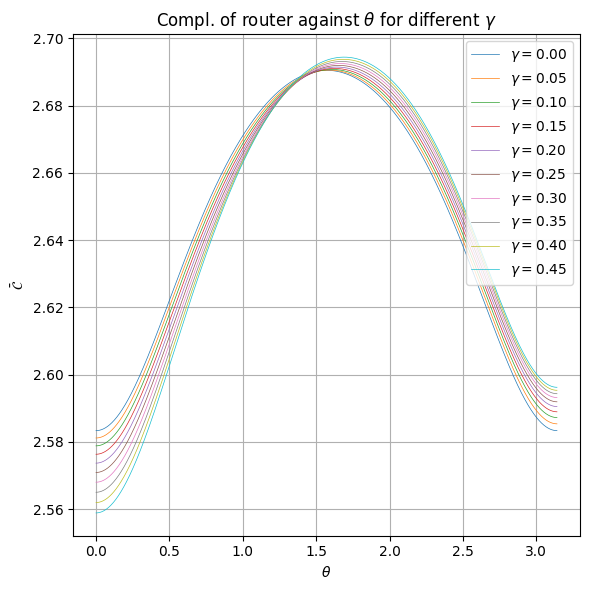

In [126]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.set_title(r"Compl. of router against $\theta$ for different $\gamma$")
axx.grid(True)

axx.set_xlabel(r"$\theta$")
axx.set_ylabel(r"$\bar{\mathcal{C}}$")

for i in range(min(10, len(gammas))):
    y=compl_gammas.real[i,:]
    axx.plot(thetas[1:-2], y[1:-2], linewidth=0.5, label=r"$\gamma=$"+f"{format(gammas[i], '.2f')}")

axx.legend(loc='upper right')

plt.show()

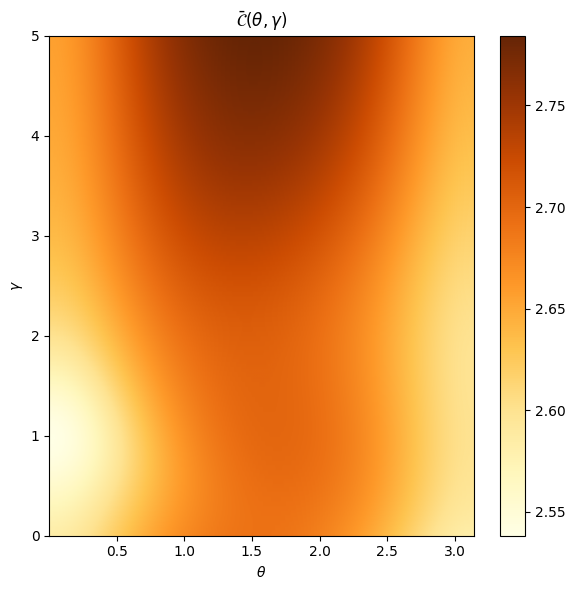

In [134]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

Z = compl_gammas.real[:,1:-2]

im = axx.imshow(Z, extent=[thetas[1], thetas[-2], gammas[0], gammas[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx, )
axx.set_aspect('auto')
axx.set_xlabel(r'$\theta$')
axx.set_ylabel(r'$\gamma$')
axx.set_title(r'$\bar{\mathcal{C}}(\theta, \gamma)$')

plt.show()